# Bloque 1. Panorama de formatos de datos en ML

**Módulo ETCDFM (5104) · UD2: Formatos de fichero de datos**

---

Elegir el formato de fichero adecuado puede marcar la diferencia entre un pipeline lento y costoso y uno eficiente y mantenible. En este bloque hacemos un recorrido general por los formatos más habituales: su clasificación, características, criterios de elección y tendencias actuales en el sector.


## Contenidos

1. Clasificación de formatos: texto vs binario; orientación por filas vs columnar
2. Tabla comparativa de formatos para ML
3. Demostración: tamaño de fichero según formato
4. Criterios de elección de formato
5. Formatos y ubicación: local, nube y sistemas distribuidos
6. Tendencias actuales


## 1.1 Clasificación de formatos

Los formatos de datos se clasifican desde dos perspectivas:

**Por codificación:**
- **Texto plano** — legibles con cualquier editor. Portables e inspeccionables, pero más lentos y voluminosos.
- **Binarios** — no legibles directamente, pero más compactos y rápidos de leer/escribir.

**Por orientación de almacenamiento:**
- **Por filas** (*row-oriented*) — todos los campos de un registro se almacenan juntos. Óptimo para insertar o leer registros completos (OLTP).
- **Por columnas** (*columnar*) — todos los valores de un campo se almacenan juntos. Óptimo para análisis y ML: se leen solo las columnas necesarias, y la compresión es más eficiente.


![Taxonomía de los formatos de datos](imagenes/b1_taxonomia_formatos.png)

## Orientacion por filas vs por columnas

La **orientación de almacenamiento** determina cómo se distribuyen físicamente los datos en disco.

| | Por filas | Por columnas |
|---|---|---|
| Almacenamiento | Todos los campos de un registro juntos | Todos los valores de un campo juntos |
| Lectura de una fila | Muy rápida | Lenta (hay que reconstruirla) |
| Lectura de una columna | Lenta (hay que saltar) | Muy rápida |
| Compresión | Moderada | Alta (valores similares juntos) |
| Ideal para | Inserción/consulta de registros (OLTP) | Análisis, agregaciones, ML (OLAP) |
| Ejemplos | CSV, Excel, Avro, Protobuf | Parquet, HDF5, Arrow/Feather |


![Orientación del almacenamiento en disco](imagenes/b1_filas_vs_columnas.png)

## 1.2 Tabla comparativa de formatos

A continuación se comparan los formatos más habituales en proyectos de ML según sus características clave:
codificación, orientación, soporte de esquema, compresión nativa, compatibilidad con streaming y uso típico.


### Tabla comparativa de formatos para ML

| Formato | Tipo | Orientación | Esquema | Compresión | Streaming | Uso típico en ML |
|---------|------|-------------|---------|------------|-----------|------------------|
| **CSV** | Texto | Filas | No | No | Sí | Datos tabulares sencillos |
| **Excel** | Binario | Filas | Parcial | Sí | No | Informes, datos de negocio |
| **XML** | Texto | Jerárquico | Sí (XSD) | No | No | Intercambio de datos |
| **JSON** | Texto | Jerárquico | Sí (JSON Schema) | No | No | API REST, configuración |
| **NDJSON** | Texto | Filas | No | No | Sí | Logs, eventos en tiempo real |
| **Parquet** | Binario | Columnar | Sí | Sí | No | Data lake, entrenamiento de ML |
| **HDF5** | Binario | Columnar | Sí | Sí | No | Arrays numéricos grandes, deep learning |
| **Arrow / Feather** | Binario | Columnar | Sí | Sí | Sí | Transferencia en memoria, IPC |
| **Avro** | Binario | Filas | Sí | Sí | Sí | Kafka, Hadoop, pipelines |
| **Protobuf** | Binario | Filas | Sí | Sí | Sí | TensorFlow, microservicios |

## Demo: tamaño de fichero según formato

Una forma directa de ver la diferencia entre formatos es guardar el mismo dataset en varios formatos y comparar el espacio ocupado en disco.

El siguiente código crea un dataset sintético de 100 000 filas y lo guarda en CSV, JSON, Excel y Parquet, midiendo el tamaño resultante.


Dataset: 100,000 filas x 5 columnas


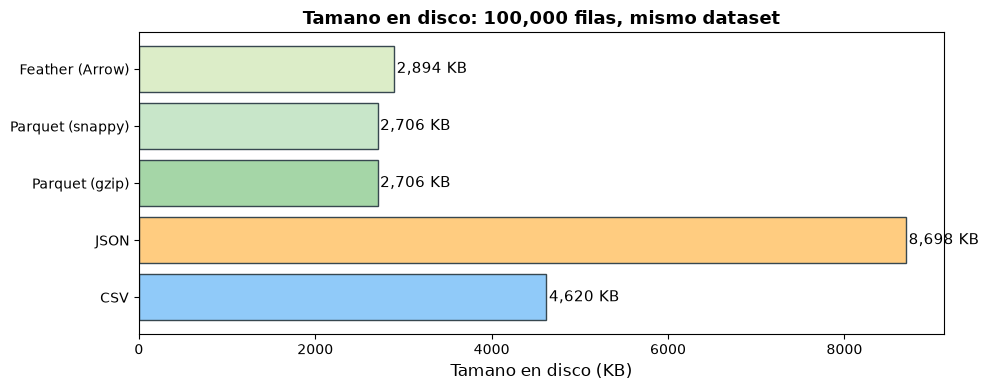

In [11]:
import pandas as pd
import numpy as np
import os, tempfile, matplotlib.pyplot as plt

# Dataset sintetico
np.random.seed(42)
N = 100_000
df = pd.DataFrame({
    'id':        range(N),
    'nombre':    [f'item_{i:06d}' for i in range(N)],
    'valor':     np.random.randn(N),
    'categoria': np.random.choice(['A', 'B', 'C', 'D'], N),
    'precio':    np.random.uniform(1, 1000, N).round(2),
})
print(f'Dataset: {len(df):,} filas x {len(df.columns)} columnas')

# Guardar en varios formatos
tmpdir = tempfile.mkdtemp()
df.to_csv(f'{tmpdir}/data.csv', index=False)
df.to_json(f'{tmpdir}/data.json', orient='records')
df.to_parquet(f'{tmpdir}/data.parquet')
df.to_parquet(f'{tmpdir}/data_snappy.parquet', compression='snappy')
df.to_feather(f'{tmpdir}/data.feather')

# Comparar tamanos
formatos_demo = {
    'CSV':               f'{tmpdir}/data.csv',
    'JSON':              f'{tmpdir}/data.json',
    'Parquet (gzip)':    f'{tmpdir}/data.parquet',
    'Parquet (snappy)':  f'{tmpdir}/data_snappy.parquet',
    'Feather (Arrow)':   f'{tmpdir}/data.feather',
}
sizes_kb = {k: os.path.getsize(v) / 1024 for k, v in formatos_demo.items()}

colors = ['#90CAF9', '#FFCC80', '#A5D6A7', '#C8E6C9', '#DCEDC8']
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(list(sizes_kb.keys()), list(sizes_kb.values()), color=colors, edgecolor='#37474F')
ax.set_xlabel('Tamano en disco (KB)', fontsize=12)
ax.set_title(f'Tamano en disco: {N:,} filas, mismo dataset', fontsize=13, fontweight='bold')
for bar, val in zip(bars, sizes_kb.values()):
    ax.text(val + 30, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f} KB', va='center', fontsize=11)
plt.tight_layout()
plt.show()


## 1.3 Criterios de elección de formato

No existe un formato universalmente mejor. La elección depende de:

| Criterio | Pregunta clave | Implicacion |
|---|---|---|
| **Tamaño** | ¿El dataset es mayor de 1 GB? | Binario columnar (Parquet, HDF5) |
| **Velocidad** | ¿Es crítica la velocidad de lectura analítica? | Parquet, Arrow |
| **Interoperabilidad** | ¿Lo leerán otras herramientas/equipos? | CSV, JSON |
| **Esquema** | ¿Necesito garantizar los tipos de datos? | Parquet, Avro, Protobuf |
| **Streaming** | ¿Los datos llegan registro a registro? | NDJSON, Avro, Protobuf |
| **Herramientas ML** | ¿Qué framework voy a usar? | Parquet (sklearn, XGBoost), HDF5 (Keras) |
| **Nube** | ¿Los datos están en S3 / GCS / Azure? | Parquet con particionado |


![Criterios clave para elegir formato de datos](imagenes/b1_criterios_eleccion.png)

## 1.4 Formatos y ubicación de los datos

Los datos no siempre están en el disco local. Según el entorno, el formato condiciona dónde y cómo se pueden usar:

| Ubicacion | Formatos habituales | Herramientas de acceso |
|---|---|---|
| **Local** | CSV, Excel, JSON, Parquet, HDF5 | pandas, h5py, pyarrow |
| **Nube** (S3, GCS, Azure) | Parquet, CSV, NDJSON | pyarrow + s3fs / gcsfs / adlfs |
| **HDFS / Spark** | Parquet, Avro, ORC | PySpark, Hive |
| **Streams** (Kafka, Pub/Sub) | Avro, Protobuf, NDJSON | confluent-kafka, fastavro |

La tendencia en la industria es almacenar en **Parquet sobre almacenamiento objeto en la nube** y leerlo directamente sin descarga completa, gracias al *filter pushdown* y el *projection pushdown* de pyarrow.


![Formatos según la ubicación de los datos](imagenes/b1_formatos_ubicacion.png)

## 1.5 Tendencias actuales

**Parquet como estándar de data lake**
Los sistemas lakehouse (Delta Lake, Apache Iceberg, Apache Hudi) usan Parquet como base. Es el formato de facto para datasets de entrenamiento a gran escala en la nube.

**Apache Arrow como estándar de transferencia en memoria**
Arrow define una representación columnar en RAM que elimina copias entre herramientas (pandas 2.0, DuckDB, Polars, Spark, R). Feather es Arrow serializado a disco.

**NDJSON en pipelines de ingesta**
Una línea = un registro JSON. Ideal para logs, exports de MongoDB/Elasticsearch y feeds de eventos en la capa de ingesta de pipelines ML.

**El binario supera al texto en producción**
Parquet puede ser 5–20x más pequeño que CSV para el mismo dataset y leerse 10–50x más rápido en consultas analíticas.


![Tendencias dominantes en el ecosistema de datos para ML (2025)](imagenes/b1_tendencias.png)

## Resumen del bloque

- Los formatos se clasifican por **codificación** (texto / binario) y **orientación** (filas / columnar).
- Los formatos **columnares binarios** (Parquet, HDF5, Arrow) son los más eficientes para ML: menos espacio, lectura más rápida, esquema integrado.
- La elección del formato depende del **tamaño**, **velocidad**, **interoperabilidad**, **esquema** y **entorno** de ejecución.
- En la nube, **Parquet** es el estándar; en memoria, **Arrow**; en streaming, **NDJSON / Avro / Protobuf**.
- Los bloques 2 al 5 de esta unidad desarrollan en profundidad cada familia de formatos.
